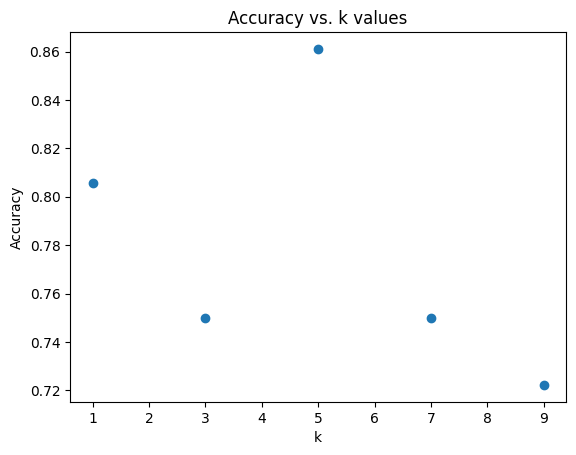

Best value of k: 5


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Define the k values to test
k_values = [1, 3, 5, 7, 9]
# Train a KNN classifier for each value of k and record the accuracy scores
accuracy_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)
    accuracy_scores.append(accuracy)
# Plot accuracy against k values
plt.scatter(k_values, accuracy_scores)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. k values")
plt.show()
k_values = range(1, 30)
accuracy_scores = []
# Apply KNN for different values of k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
# Print the best value of k
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]
print("Best value of k:", best_k)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Define the p values to test
p_values = [1, 2, 3, 4, 5]
# Train a KNN classifier for each value of p and record the accuracy scores
accuracy_scores = []
for p in p_values:
    knn = KNeighborsClassifier(n_neighbors=5, p=p)
    # Adjust n_neighbors as needed
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
# Print the accuracy scores for each p value
print("Accuracy scores for each p value:")
for p, accuracy in zip(p_values, accuracy_scores):
  print(f"p={p}: {accuracy}")
print()

Accuracy scores for each p value:
p=1: 0.8055555555555556
p=2: 0.7222222222222222
p=3: 0.7222222222222222
p=4: 0.7222222222222222
p=5: 0.7222222222222222



In [ ]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('income_evaluation.csv')
df.head()

# Identify categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(exclude=['object']).columns

# Apply one-hot encoding to categorical features
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Separate features and target variable again after one-hot encoding
X = df.drop("income_ >50K", axis=1)
# Adjust target column name based on get_dummies output
y = df["income_ >50K"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

display(X_train.head())
svc = SVC(random_state=101)
svc.fit(X_train,y_train)
accuracies = cross_val_score(svc,X_train,y_train,cv=5)
print("Train Score:", np.mean(accuracies))
print("Test Score:", svc.score(X_test,y_test))

grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],  # only fast, common kernels
    'gamma': ['scale', 'auto']    # use built-in gamma values
}

svm = SVC ()

svm_cv = GridSearchCV(svm, grid, cv = 5)
svm_cv.fit(X_train,y_train)
print("Best Parameters:",svm_cv.best_params_)
print("Train Score:",svm_cv.best_score_)
print("Test Score:",svm_cv.score(X_test,y_test))

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
4400,-0.996110,-0.550200,-1.222152,-0.147881,-0.221529,-2.351924,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2598,0.181302,-0.077999,-0.427479,-0.147881,-0.221529,0.791095,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
496,-1.364051,0.666475,-0.030143,-0.147881,-0.221529,-0.036015,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4915,-1.511228,-0.028649,-1.222152,-0.147881,-0.221529,-1.690236,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1341,1.358714,-0.955980,1.559203,-0.147881,-0.221529,-0.036015,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


Train Score: 0.8461355529131985
Test Score: 0.8488593155893536
Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Train Score: 0.848038049940547
Test Score: 0.8479087452471483


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
log_clf =LogisticRegression()
rnd_clf=RandomForestClassifier()
svm_clf=SVC()
voting_clf=VotingClassifier(
estimators=[('lr',log_clf),('rf',rnd_clf),('svc',svm_clf)], voting='hard' )
voting_clf.fit(X_train,y_train)
y_pred = voting_clf.predict(X_test)
print("Predictions:", y_pred[:10])  # show first 10 predictions


from sklearn.metrics import accuracy_score
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
  clf.fit(X_train, y_train)
  y_pred=clf.predict(X_test)
  print(clf.__class__.__name__,accuracy_score(y_test,y_pred))

Predictions: [False False False  True  True False False False False False]
LogisticRegression 0.8450570342205324
RandomForestClassifier 0.8450570342205324
SVC 0.8488593155893536
VotingClassifier 0.8498098859315589
